In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
books=pd.read_csv('Datasets/BX-Books.csv',encoding='latin-1')
users=pd.read_csv('Datasets/BX-Users.csv',encoding='latin-1')
ratings=pd.read_csv('Datasets/BX-Book-Ratings.csv',encoding='latin-1')

C:\Users\azart\AppData\Local\Temp\ipykernel_1624\2784735546.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books=pd.read_csv('Datasets/BX-Books.csv',encoding='latin-1')
C:\Users\azart\AppData\Local\Temp\ipykernel_1624\2784735546.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  users=pd.read_csv('Datasets/BX-Users.csv',encoding='latin-1')


In [4]:
print(ratings.shape)

(1048575, 3)


In [5]:
ratings.head()

,user_id,isbn,rating
0,276725,034545104X,0
1,276726,155061224,5
2,276727,446520802,0
3,276729,052165615X,3
4,276729,521795028,6


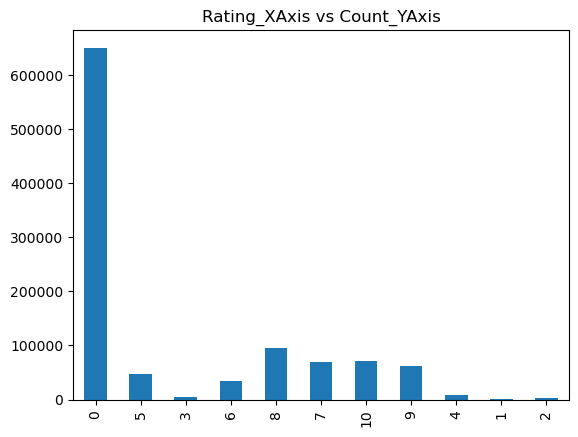

         user_id        isbn  rating
0         276725  034545104X       0
1         276726   155061224       5
2         276727   446520802       0
3         276729  052165615X       3
4         276729   521795028       6
...          ...         ...     ...
1048570   250764   451410777       0
1048571   250764   452264464       8
1048572   250764  048623715X       0
1048573   250764   486256588       0
1048574   250764   515069434       0

[1048575 rows x 3 columns]


In [6]:
# plt.rc("font",size=15)
ratings.rating.value_counts(sort=False).plot(kind="bar")
plt.title("Rating_XAxis vs Count_YAxis")
plt.show()
print(ratings)

In [7]:
print(books.shape)
print(list(books.columns))
books.head()

(271379, 5)
['isbn', 'book_title', 'book_author', 'year_of_publication', 'publisher']


,isbn,book_title,book_author,year_of_publication,publisher
0,195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,2005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,60973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


In [8]:
print(users.shape)
print(list(users.columns))
print(users.head())

(278859, 3)
['user_id', 'Location', 'Age']
  user_id                            Location   Age
0       1                  nyc, new york, usa   NaN
1       2           stockton, california, usa  18.0
2       3     moscow, yukon territory, russia   NaN
3       4           porto, v.n.gaia, portugal  17.0
4       5  farnborough, hants, united kingdom   NaN


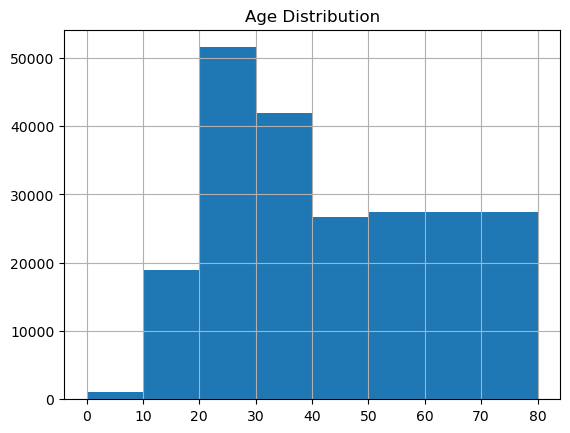

In [9]:
users.Age.hist(bins=[0,10,20,30,40,50,80])
plt.title("Age Distribution")
plt.show()

In [10]:
rating_count=pd.DataFrame(ratings.groupby('isbn')['rating'].count())
rating_count.sort_values('rating',ascending=False).head()

,rating
isbn,
971880107,2264
316666343,1164
385504209,813
312195516,668
60928336,662


In [11]:
most_rated_books=pd.DataFrame(['971880107','316666343','385504209','312195516','60928336'], index=np.arange(5),columns=['isbn'])
most_rated_books_summary=pd.merge(most_rated_books,books,on='isbn')
most_rated_books_summary

,isbn,book_title,book_author,year_of_publication,publisher
0,971880107,Wild Animus,Rich Shapero,2004,Too Far
1,316666343,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown"
2,385504209,The Da Vinci Code,Dan Brown,2003,Doubleday
3,312195516,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA
4,60928336,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,1997,Perennial


In [12]:
average_rating = pd.DataFrame(ratings.groupby('isbn')['rating'].mean())
average_rating['ratingCount'] = pd.DataFrame(ratings.groupby('isbn')['rating'].count())
average_rating.sort_values('ratingCount', ascending=False).head()

,rating,ratingCount
isbn,,
971880107,1.032244,2264
316666343,4.457045,1164
385504209,4.691267,813
312195516,4.326347,668
60928336,3.462236,662


In [14]:
counts1=ratings['user_id'].value_counts()
ratings=ratings[ratings['user_id'].isin(counts1[counts1>=200].index)]
ratings

,user_id,isbn,rating
1456,277427,002542730X,10
1457,277427,26217457,0
1458,277427,003008685X,8
1459,277427,30615321,0
1460,277427,60002050,0
...,...,...,...
1048570,250764,451410777,0
1048571,250764,452264464,8
1048572,250764,048623715X,0
1048573,250764,486256588,0


In [17]:
counts=ratings['rating'].value_counts()
ratings=ratings[ratings['rating'].isin(counts[counts>=100].index)]
ratings

,user_id,isbn,rating
1456,277427,002542730X,10
1457,277427,26217457,0
1458,277427,003008685X,8
1459,277427,30615321,0
1460,277427,60002050,0
...,...,...,...
1048570,250764,451410777,0
1048571,250764,452264464,8
1048572,250764,048623715X,0
1048573,250764,486256588,0
